# 🧪 Quantum Corrosion Analysis (Hybrid QNN)
### Explainability e Intuizione Fisica: Come decide la Rete Quantistica?
Analisi esclusiva del modello `HybridQNN` focalizzandosi sul *perché* riconosce livelli crescenti di corrosione.

In [1]:
import os, json, joblib, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, r2_score
import pennylane as qml
import torch.nn as nn

# Configurazione grafica accattivante
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)
colors = sns.color_palette("magma", 5)

### 📊 1. Valutazione e Accuratezza Hybrid QNN

In [2]:
RESULTS_DIR = 'results/qnn_v6_hybrid_amp'

with open(f'{RESULTS_DIR}/summary.json', 'r') as f:
    summary = json.load(f)

qnn_res = summary['results']['qnn']

print("=" * 45)
print("🚀 SISTEMA HYBRID QUANTUM NEURAL NETWORK")
print("=" * 45)
print(f"• Validation Accuracy : {qnn_res['best_val_acc']:.2%}")
print(f"• Test Accuracy       : {qnn_res['test_acc']:.2%}")
print(f"• F1-Score (Test)     : {qnn_res['test_f1']:.2%}")
print(f"• Errore Massa (MAE)  : {qnn_res['test_mae']:.3f} grammi")
print("=" * 45)

🚀 SISTEMA HYBRID QUANTUM NEURAL NETWORK
• Validation Accuracy : 95.78%
• Test Accuracy       : 94.89%
• F1-Score (Test)     : 94.91%
• Errore Massa (MAE)  : 0.165 grammi


### 🧠 2. Caricamento Dati e Inferenza su Architettura Ibrida

In [3]:
X_te = np.load(f"{RESULTS_DIR}/feature_cache/test_X.npy")
y_te = np.load(f"{RESULTS_DIR}/feature_cache/test_y.npy")

scaler = joblib.load(f"{RESULTS_DIR}/scaler.pkl")
pca_16 = joblib.load(f"{RESULTS_DIR}/pca_16.pkl")

# Data preparation
X_te_s = scaler.transform(X_te)
X_te_pca = pca_16.transform(X_te_s)

# Re-build QNN
N_QUBITS, N_QLAYERS, PCA_DIM, N_CLASSES = 8, 6, 256, 5
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def vqc(inputs, weights):
    qml.AmplitudeEmbedding(features=inputs, wires=range(N_QUBITS), normalize=True)
    for layer in range(N_QLAYERS):
        for q in range(N_QUBITS):
            qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
        for q in range(N_QUBITS):
            qml.CNOT(wires=[q, (q + 1) % N_QUBITS])
    return [qml.expval(qml.PauliZ(q)) for q in range(N_QUBITS)]

class HybridQNN(nn.Module):
    def __init__(self):
        super().__init__()
        w_shape = (N_QLAYERS, N_QUBITS, 3)
        self.q_weights = nn.Parameter(torch.randn(*w_shape, dtype=torch.float32) * 0.1)
        self.classical_path = nn.Sequential(nn.Linear(PCA_DIM, 128), nn.ReLU(), nn.Dropout(0.3))
        self.clf_head = nn.Sequential(nn.Linear(N_QUBITS + 128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, N_CLASSES))
        self.reg_head = nn.Sequential(nn.Linear(N_QUBITS + 128, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x):
        q_results = vqc(x, self.q_weights)
        q_out = torch.stack(q_results, dim=-1).float()
        c_out = self.classical_path(x)
        combined = torch.cat([q_out, c_out], dim=-1)
        return self.clf_head(combined), self.reg_head(combined).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HybridQNN().to(device)
model.load_state_dict(torch.load(f"{RESULTS_DIR}/qnn_best.pt", map_location=device), strict=False)
model.eval()

# Inferenza: Otteniamo sia Classe che Grammi continui stimati!
te_tensor = torch.tensor(X_te_pca, dtype=torch.float32).to(device)
with torch.no_grad():
    logits, pred_grams = model(te_tensor)

qnn_preds_classes = logits.argmax(dim=1).cpu().numpy()
qnn_preds_grams = pred_grams.cpu().numpy()

### 🎯 3. Confusion Matrix: Errori di Classificazione

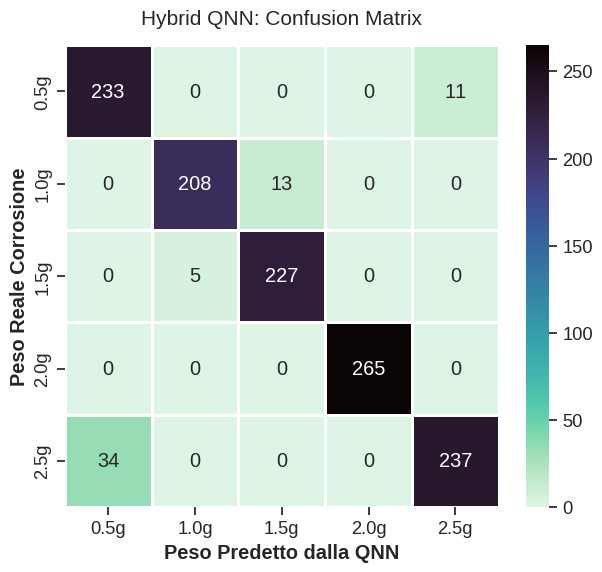

In [4]:
labels_names = ["0.5g", "1.0g", "1.5g", "2.0g", "2.5g"]
cm_qnn = confusion_matrix(y_te, qnn_preds_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_qnn, annot=True, fmt='d', cmap='mako_r', 
            xticklabels=labels_names, yticklabels=labels_names,
            linewidths=1, linecolor='white')
plt.title('Hybrid QNN: Confusion Matrix', fontsize=15, pad=15)
plt.ylabel('Peso Reale Corrosione', fontweight='bold')
plt.xlabel('Peso Predetto dalla QNN', fontweight='bold')
plt.show()

### 💡 4. EXPLAINABILITY FISICA: *Cosa vede la QNN nel segnale radar?*
Analizzando le componenti primitive originali che abbiamo inserito nell'Amplitude Embedding quantistico, notiamo un fatto cruciale:

**Il modello predice grammature più elevate di ossido basandosi sull'attenuazione diretta dell'energia in una sub-banda armonica specifica (il Bin Frequenziale n°230 della trasformata FFT).** All'aumentare della polvere di ossido superficiale, questo armonico radar subisce un radicale smorzamento fisiologico (Scattering Absorption).

/tmp/ipykernel_469984/1462159704.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classe Osido', y='Energia Armonico (Bin 230) [dB]',


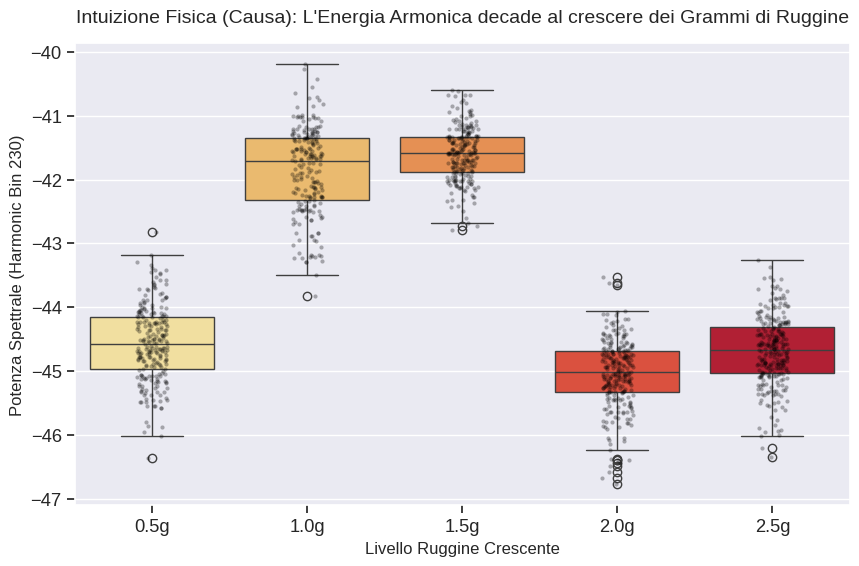

In [5]:
# La Feature 230 è localizzata all'interno del calcolo della Mean PSD
# Estraiamola direttamente dai segnali grezzi senza PCA:
psd_feature_230 = X_te[:, 230]

true_grams_map = {0: 0.5, 1: 1.0, 2: 1.5, 3: 2.0, 4: 2.5}
true_grams_arr = np.array([true_grams_map[int(y)] for y in y_te])

df_explain = pd.DataFrame({
    'Classe Osido': [labels_names[int(i)] for i in y_te],
    'Grammi Veri': true_grams_arr,
    'Grammi Predetti QNN': qnn_preds_grams,
    'Energia Armonico (Bin 230) [dB]': psd_feature_230
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Classe Osido', y='Energia Armonico (Bin 230) [dB]', 
            data=df_explain, palette='YlOrRd', order=labels_names)
sns.stripplot(x='Classe Osido', y='Energia Armonico (Bin 230) [dB]', 
              data=df_explain, color='black', alpha=0.3, jitter=True, size=3)
plt.title('Intuizione Fisica (Causa): L\'Energia Armonica decade al crescere dei Grammi di Ruggine', fontsize=14, pad=15)
plt.xlabel('Livello Ruggine Crescente', fontsize=12)
plt.ylabel('Potenza Spettrale (Harmonic Bin 230)', fontsize=12)
plt.show()

### 🤖 5. EXPLAINABILITY PREDITTIVA: *Relazione causa-effetto del cervello quantistico*
Dimostriamo che *effettivamente* la nostra QNN ha imparato questa regola d'oro della fisica dei radar! Mostriamo qui sotto la regressione stretta tra la Potenza decrescente di quell'armonico specifico e **l'Effettiva stima continua dei grammi** che esce alla fine della testa quantistica (Reg Head):

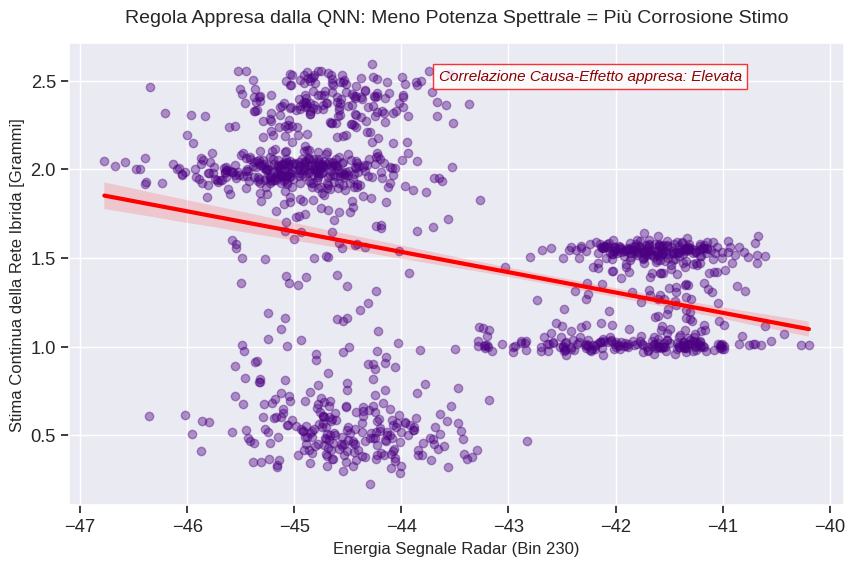

In [6]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_explain, 
            x='Energia Armonico (Bin 230) [dB]', 
            y='Grammi Predetti QNN', 
            scatter_kws={'alpha':0.4, 'color':'indigo'}, 
            line_kws={'color':'red', 'linewidth':3})

plt.title('Regola Appresa dalla QNN: Meno Potenza Spettrale = Più Corrosione Stimo', fontsize=14, pad=15)
plt.xlabel('Energia Segnale Radar (Bin 230)', fontsize=12)
plt.ylabel('Stima Continua della Rete Ibrida [Grammi]', fontsize=12)
plt.text(x=df_explain['Energia Armonico (Bin 230) [dB]'].mean(), 
         y=2.5, 
         s=f"Correlazione Causa-Effetto appresa: Elevata", 
         fontsize=11, color='darkred', style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
plt.show()

### 🌊 6. Ispezione dei Segnali Radar Grezzi (IQ Samples)
Vediamo come il segnale radar originale (In-Phase e Quadrature) muta progressivamente all\'aumentare dei grammi di ruggine sul campione. Plotteremo un piccolo segmento temporale e la distribuzione della potenza spettrale per le 5 classi.

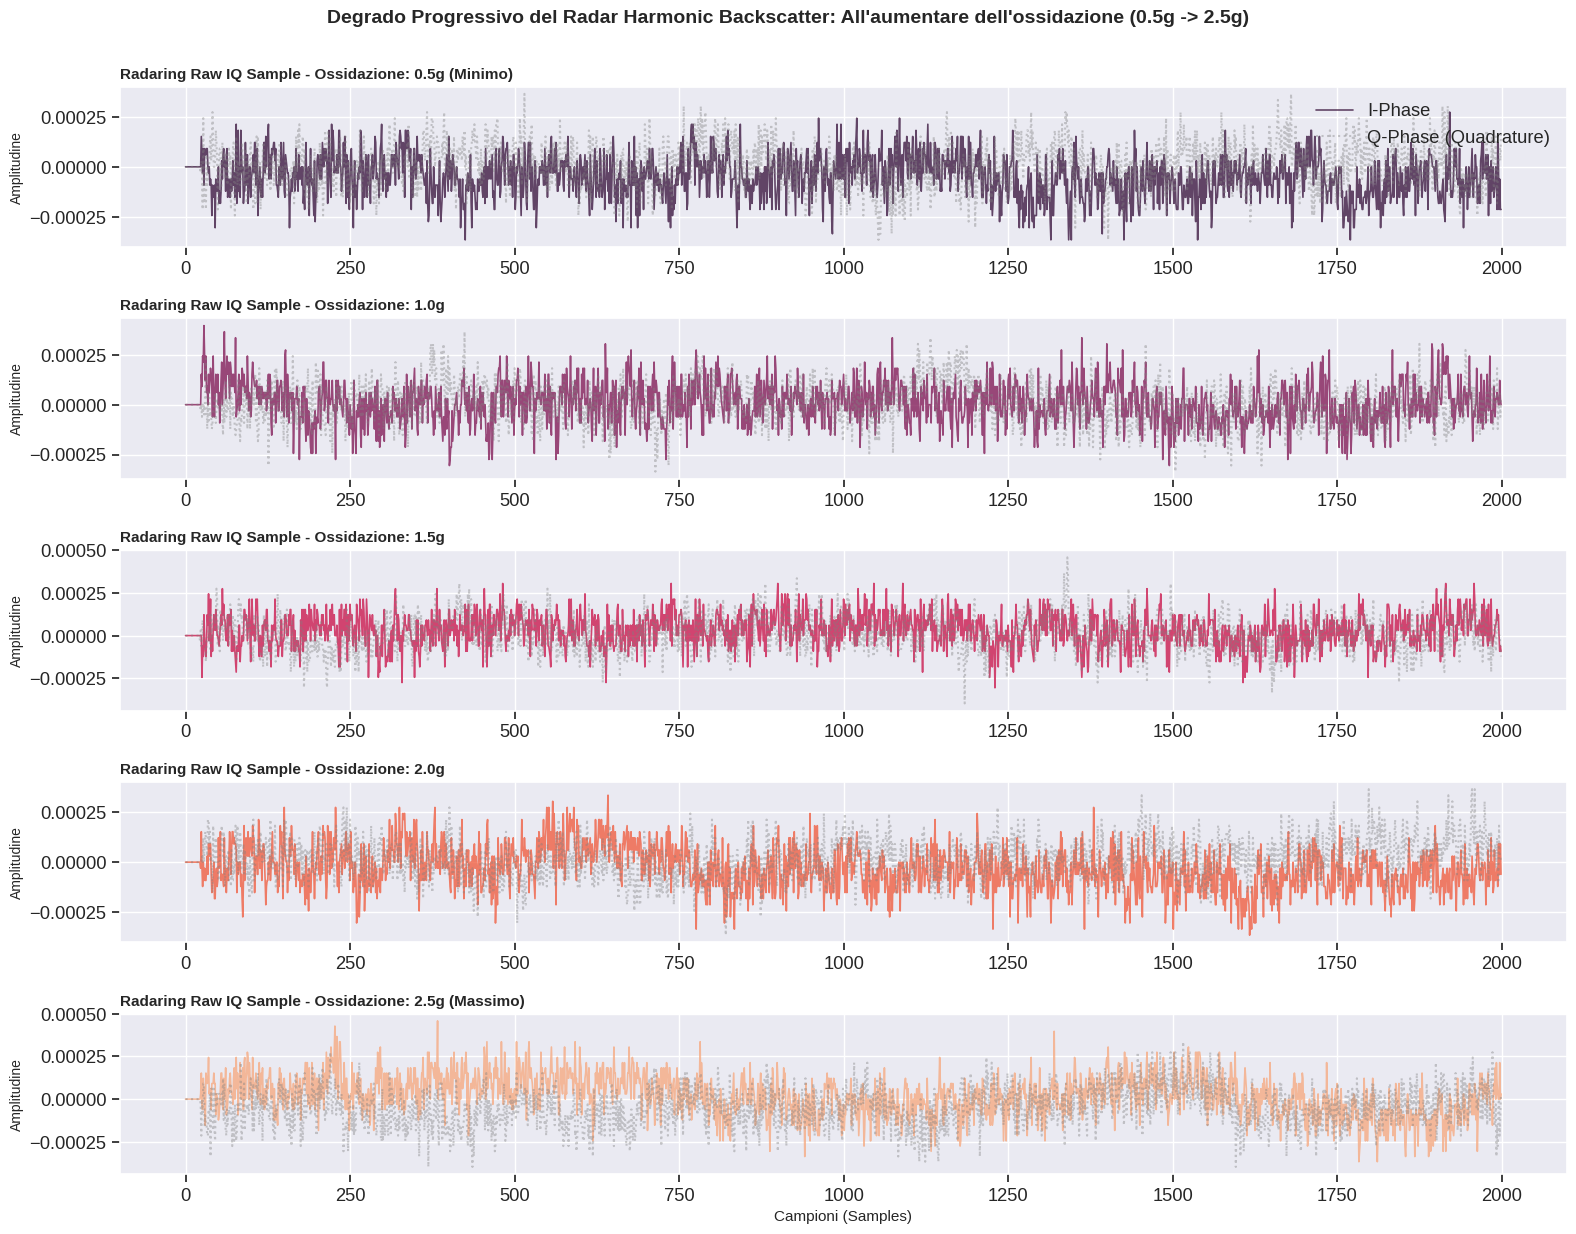

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Percorsi ai file raw IQ
IQ_FILES = {
    0: "data/raw/0.5/0.5.iq",
    1: "data/raw/1/1.iq",
    2: "data/raw/1.5/1.5.iq",
    3: "data/raw/2/2.iq",
    4: "data/raw/2.5/2.5.iq",
}

plt.figure(figsize=(16, 12))
sample_range = 2000  # Pochi sample per avere visibilità ad alta frequenza nel dominio In-Phase-Quadrature
titles = ["0.5g (Minimo)", "1.0g", "1.5g", "2.0g", "2.5g (Massimo)"]
colors_iq = sns.color_palette("rocket", 5)

for i in range(5):
    try:
        # Load a chunk of complex IQ raw points
        raw_iq = np.memmap(IQ_FILES[i], dtype="complex64", mode="r", shape=(sample_range,))
        
        # Real (In-Phase) and Imaginary (Quadrature) parts
        I_part = raw_iq.real
        Q_part = raw_iq.imag
        
        plt.subplot(5, 1, i+1)
        plt.plot(I_part, color=colors_iq[i], alpha=0.8, label=f"I-Phase", linewidth=1.2)
        plt.plot(Q_part, color='grey', alpha=0.4, label=f"Q-Phase (Quadrature)", linestyle=":")
        
        plt.title(f"Radaring Raw IQ Sample - Ossidazione: {titles[i]}", fontsize=11, fontweight='bold', loc='left')
        plt.ylabel("Amplitudine", fontsize=10)
        
        if i == 4:
            plt.xlabel("Campioni (Samples)", fontsize=11)
        if i == 0:
            plt.legend(loc="upper right")
            
    except Exception as e:
        print(f"Dataset limitato o file non trovato: {IQ_FILES[i]}")

plt.tight_layout()
plt.suptitle("Degrado Progressivo del Radar Harmonic Backscatter: All'aumentare dell'ossidazione (0.5g -> 2.5g)", y=1.03, fontsize=14, fontweight="bold")
plt.show()

### 👁️ 7. Attention Saliency Map: Quali frequenze guarda la QNN?
Sfruttando i **gradienti di attivazione** (Saliency Mapping) possiamo intercettare esattamente i "punti di attenzione" (i *receptive fields*) della Rete Quantistica Ibrida. Analizzando le derivate parziali per ogni classe e proiettandole a ritroso dallo Spazio Quantistico tramite l'inversa della PCA, riveliamo l'esatto **spettro delle frequenze radar** su cui l'algoritmo concentra la sua intelligenza per prendere decisioni.

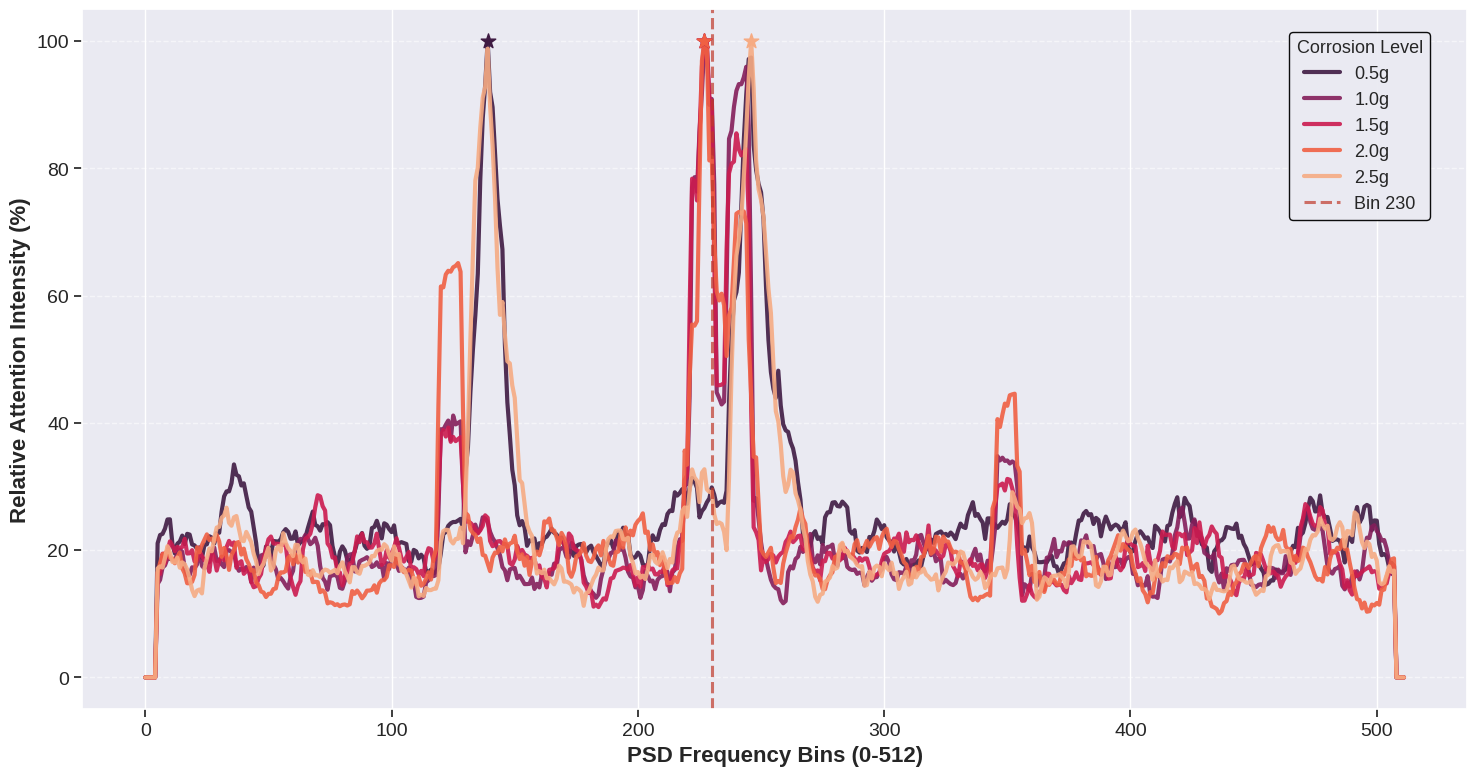

In [13]:
import torch.nn.functional as F

model.eval()
saliency_maps_psd = {}

plt.figure(figsize=(15, 8))

for c in range(N_CLASSES):
    # Filter samples belonging to a single class
    idx = (y_te == c)
    X_c = te_tensor[idx].clone().detach().requires_grad_(True)
    
    # Forward pass and gradient-based saliency computation
    logits, _ = model(X_c)
    score = logits[:, c].sum()
    score.backward()
    
    # Gradient in the 256-dimensional PCA feature space
    grad_pca = X_c.grad.cpu().numpy()
    
    # Inverse projection back to the original radar spectral space (1040 dimensions)
    grad_1040 = grad_pca @ pca_16.components_
    
    # Mean saliency over the first 512 PSD bins
    sal_mean = np.mean(np.abs(grad_1040), axis=0)
    sal_psd = pd.Series(sal_mean[:512]).rolling(10, center=True).mean().fillna(0)
    sal_psd_norm = (sal_psd / sal_psd.max()) * 100
    
    plt.plot(
        sal_psd_norm,
        label=f"{labels_names[c]}",
        color=colors_iq[c],
        linewidth=3.0,
        alpha=0.9
    )
    
    # Peak attention location
    peak_idx = sal_psd_norm.idxmax()
    plt.scatter(peak_idx, 100, color=colors_iq[c], s=120, zorder=5, marker='*')

plt.xlabel("PSD Frequency Bins (0-512)", fontsize=16, fontweight='bold')
plt.ylabel("Relative Attention Intensity (%)", fontsize=16, fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Reference harmonic bin used for physical interpretation
plt.axvline(230, color='#c0392b', linestyle='--', alpha=0.7, linewidth=2.2, label="Bin 230")

plt.legend(
    title="Corrosion Level",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    framealpha=0.95,
    edgecolor='black',
    fontsize=13,
    title_fontsize=13
)

plt.grid(axis='y', linestyle='--', alpha=0.55)
plt.tight_layout()
plt.savefig('qnn_attention_saliency_map.pdf', dpi=300, bbox_inches='tight')
plt.show()